# V2 Layer-Balanced Initialization: η Sweep Analysis

**Goal**: Push the gradient ratio of the V2 (layer-balanced) initialization toward 1×.

From the meeting walkthrough (Sections 6–7), the V2 initializer uses per-layer variance scaling:

$$s_\ell = s^* \cdot r^{\eta(\ell - (L+1)/2)}, \quad r = \sqrt{(\pi-1)/\pi} \approx 0.826$$

The **gradient ratio** (max/min gradient row norm across layers) is theoretically:

$$G(\eta) = r^{-(1-\eta)(L-1)}$$

At $\eta=0.5$ (used in notebook 09), $G \approx 109\times$ (theory) / $36\times$ (empirical).
At $\eta=1.0$, theory predicts $G=1\times$ — but does practice agree?

The **Pareto constraint** says $G(\eta) \cdot V(\eta) = r^{-(L-1)}$ is fixed,
so reducing the gradient ratio inflates the weight variance ratio.

This notebook sweeps $\eta \in [0, 1]$ and compares **empirical** vs **theoretical** behaviour.

In [1]:
# Setup
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
import math
import warnings
warnings.filterwarnings('ignore')

from rp_study.config import ExperimentConfig, NetworkConfig, GradientExperimentConfig
from rp_study.experiments.gradient_analysis import GradientExperiment

plt.style.use('default')

In [2]:
# ====== CONFIGURATION ======

SEED = 42
DATASET = 'fashion_mnist'
DATA_DIR = '../data'
NUM_SAMPLES = 2000

_DATASET_INPUT_DIMS = {'mnist': 784, 'fashion_mnist': 784, 'cifar10': 3072}
INPUT_DIM = _DATASET_INPUT_DIMS[DATASET]

DEPTH = 50
WIDTH = INPUT_DIM
LAYER_SIZES = [INPUT_DIM] + [WIDTH] * DEPTH + [1]

# Structural centering factor
r = math.sqrt((math.pi - 1) / math.pi)  # ~0.826
s_star = (math.pi / (math.pi - 1)) ** 0.25  # ~1.1006

# Eta values for the sweep
ETAS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.65, 0.70, 0.75, 0.78, 0.80, 0.85, 0.90, 0.95, 1.0]

FIGDIR = '../reports/latex/product_balanced_report/figures'

print(f'Dataset: {DATASET} (input_dim={INPUT_DIM})')
print(f'Architecture: {DEPTH} hidden layers, width {WIDTH}')
print(f'r = {r:.6f}, s* = {s_star:.4f}')
print(f'Pareto budget at L={DEPTH}: r^{{-(L-1)}} = {r**(-(DEPTH-1)):.1f}x')
print(f'Eta values: {ETAS}')

Dataset: fashion_mnist (input_dim=784)
Architecture: 50 hidden layers, width 784
r = 0.825645, s* = 1.1005
Pareto budget at L=50: r^{-(L-1)} = 11943.1x
Eta values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.65, 0.7, 0.75, 0.78, 0.8, 0.85, 0.9, 0.95, 1.0]


## 1. Theoretical Predictions

Before running experiments, let's see what the mean-field theory predicts.

In [3]:
print(f'{"η":>6s}  {"G(η) theory":>12s}  {"V(η) theory":>12s}  {"G·V":>12s}')
print('-' * 48)
for eta in ETAS:
    G_theo = r ** (-(1 - eta) * (DEPTH - 1))
    V_theo = r ** (-eta * (DEPTH - 1))
    print(f'{eta:>6.2f}  {G_theo:>12.1f}x  {V_theo:>12.1f}x  {G_theo * V_theo:>12.1f}x')

     η   G(η) theory   V(η) theory           G·V
------------------------------------------------
  0.00       11943.1x           1.0x       11943.1x
  0.10        4671.0x           2.6x       11943.1x
  0.20        1826.8x           6.5x       11943.1x
  0.30         714.5x          16.7x       11943.1x
  0.40         279.4x          42.7x       11943.1x
  0.50         109.3x         109.3x       11943.1x
  0.60          42.7x         279.4x       11943.1x
  0.65          26.7x         446.8x       11943.1x
  0.70          16.7x         714.5x       11943.1x
  0.75          10.5x        1142.5x       11943.1x
  0.78           7.9x        1514.1x       11943.1x
  0.80           6.5x        1826.8x       11943.1x
  0.85           4.1x        2921.1x       11943.1x
  0.90           2.6x        4671.0x       11943.1x
  0.95           1.6x        7469.0x       11943.1x
  1.00           1.0x       11943.1x       11943.1x


## 2. Empirical η Sweep

Run gradient experiments for each η value and collect the empirical gradient ratio
and weight std ratio.

In [4]:
# Run experiments for all eta values
sweep_data = []  # list of dicts

for eta in ETAS:
    exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
    exp_config.setup_seeds()
    grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES, dataset=DATASET)

    net_config = NetworkConfig(
        layer_sizes=LAYER_SIZES,
        init_strategy='row_centered_layer_balanced_product_base',
        init_kwargs={'eta': eta},
    )
    exp = GradientExperiment(exp_config, net_config, grad_config)
    result = exp.run()

    # Gradient row norms (hidden layers only)
    norms = result.get_mean_row_norms()
    hidden_vals = list(norms.values())[:-1]
    grad_ratio = max(hidden_vals) / max(min(hidden_vals), 1e-30)

    # Weight std per layer
    weight_stds = [l.weight.std().item() for l in exp.net.layers[:-1]]
    wt_ratio = max(weight_stds) / max(min(weight_stds), 1e-30)

    # Theoretical values
    G_theo = r ** (-(1 - eta) * (DEPTH - 1))
    V_theo = r ** (-eta * (DEPTH - 1))

    sweep_data.append({
        'eta': eta,
        'emp_G': grad_ratio,
        'emp_V': wt_ratio,
        'theo_G': G_theo,
        'theo_V': V_theo,
        'hidden_norms': hidden_vals,
        'weight_stds': weight_stds,
        'result': result,
        'net': exp.net,
    })

    print(f'η={eta:.2f}: emp_G={grad_ratio:>8.1f}x  theo_G={G_theo:>10.1f}x  '
          f'emp_V={wt_ratio:>10.1f}x  theo_V={V_theo:>10.1f}x')

print('\nDone!')

η=0.00: emp_G=  1901.6x  theo_G=   11943.1x  emp_V=       1.0x  theo_V=       1.0x
η=0.10: emp_G=   839.2x  theo_G=    4671.0x  emp_V=       2.6x  theo_V=       2.6x
η=0.20: emp_G=   379.9x  theo_G=    1826.8x  emp_V=       6.5x  theo_V=       6.5x
η=0.30: emp_G=   171.8x  theo_G=     714.5x  emp_V=      16.7x  theo_V=      16.7x
η=0.40: emp_G=    77.8x  theo_G=     279.4x  emp_V=      42.7x  theo_V=      42.7x
η=0.50: emp_G=    36.0x  theo_G=     109.3x  emp_V=     109.3x  theo_V=     109.3x
η=0.60: emp_G=    16.6x  theo_G=      42.7x  emp_V=     279.4x  theo_V=     279.4x
η=0.65: emp_G=    11.3x  theo_G=      26.7x  emp_V=     446.8x  theo_V=     446.8x
η=0.70: emp_G=     7.7x  theo_G=      16.7x  emp_V=     714.5x  theo_V=     714.5x
η=0.75: emp_G=     6.6x  theo_G=      10.5x  emp_V=    1142.5x  theo_V=    1142.5x
η=0.78: emp_G=     6.9x  theo_G=       7.9x  emp_V=    1514.1x  theo_V=    1514.1x
η=0.80: emp_G=     7.2x  theo_G=       6.5x  emp_V=    1826.8x  theo_V=    1826.8x
η=0.

## 3. Summary Table

In [5]:
print(f'{"η":>6s}  {"Emp G":>8s}  {"Theo G":>8s}  {"Emp V":>10s}  {"Theo V":>10s}  '
      f'{"G matches?":>10s}')
print('-' * 62)

best_idx = min(range(len(sweep_data)), key=lambda i: sweep_data[i]['emp_G'])

for i, d in enumerate(sweep_data):
    marker = '  <-- BEST' if i == best_idx else ''
    print(f'{d["eta"]:>6.2f}  {d["emp_G"]:>7.1f}x  {d["theo_G"]:>7.1f}x  '
          f'{d["emp_V"]:>9.1f}x  {d["theo_V"]:>9.1f}x  '
          f'{d["emp_G"]/d["theo_G"]:>9.2f}x{marker}')

print(f'\nBest empirical gradient ratio: η={sweep_data[best_idx]["eta"]:.2f} '
      f'with G={sweep_data[best_idx]["emp_G"]:.1f}x '
      f'(weight std ratio = {sweep_data[best_idx]["emp_V"]:.1f}x)')

     η     Emp G    Theo G       Emp V      Theo V  G matches?
--------------------------------------------------------------
  0.00   1901.6x  11943.1x        1.0x        1.0x       0.16x
  0.10    839.2x   4671.0x        2.6x        2.6x       0.18x
  0.20    379.9x   1826.8x        6.5x        6.5x       0.21x
  0.30    171.8x    714.5x       16.7x       16.7x       0.24x
  0.40     77.8x    279.4x       42.7x       42.7x       0.28x
  0.50     36.0x    109.3x      109.3x      109.3x       0.33x
  0.60     16.6x     42.7x      279.4x      279.4x       0.39x
  0.65     11.3x     26.7x      446.8x      446.8x       0.42x
  0.70      7.7x     16.7x      714.5x      714.5x       0.46x
  0.75      6.6x     10.5x     1142.5x     1142.5x       0.63x  <-- BEST
  0.78      6.9x      7.9x     1514.1x     1514.1x       0.88x
  0.80      7.2x      6.5x     1826.8x     1826.8x       1.10x
  0.85      8.0x      4.1x     2921.1x     2921.1x       1.96x
  0.90      9.0x      2.6x     4671.0x     46

## 4. Plot: Empirical vs Theoretical G(η) and V(η)

This is the key figure. The left panel shows that the empirical gradient ratio
has a **U-shape** — it bottoms out around η≈0.75 instead of monotonically decreasing
to 1× as theory predicts. The middle panel confirms the weight variance ratio
matches theory exactly (it's deterministic). The right panel shows the resulting
empirical Pareto frontier.

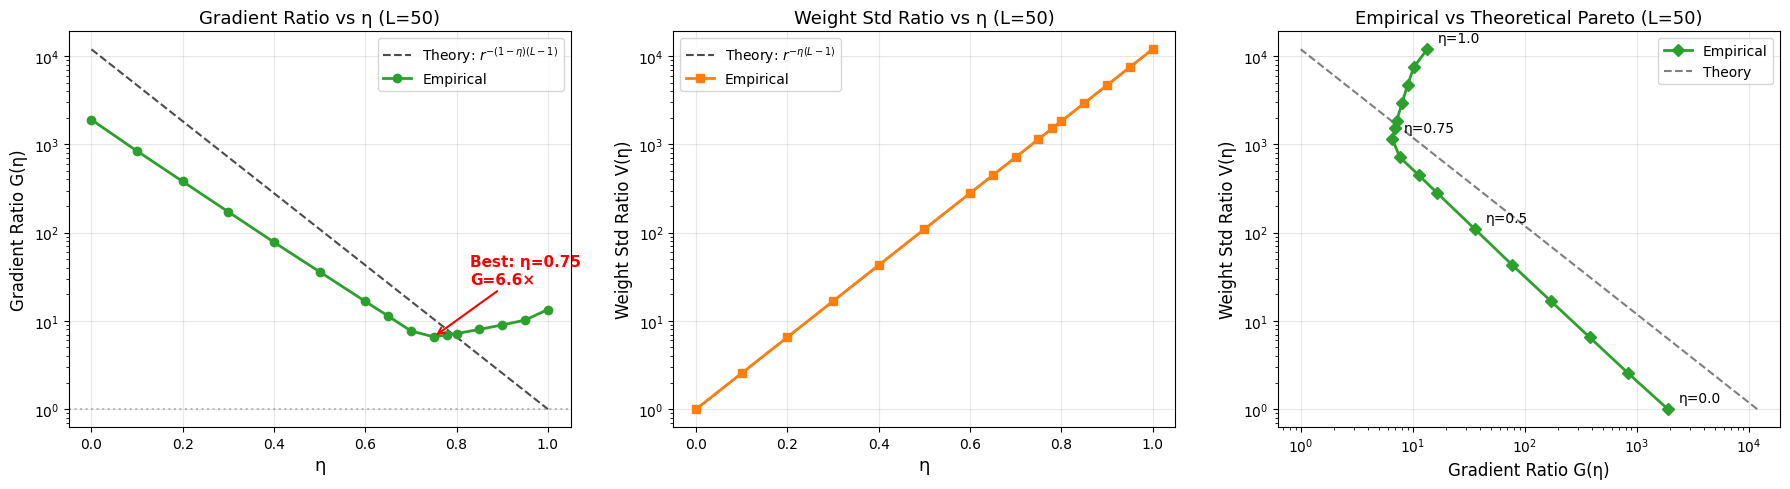

Saved to ../reports/latex/product_balanced_report/figures/eta_sweep_L50.png


In [6]:
etas_arr = [d['eta'] for d in sweep_data]
emp_G = [d['emp_G'] for d in sweep_data]
emp_V = [d['emp_V'] for d in sweep_data]
theo_G = [d['theo_G'] for d in sweep_data]
theo_V = [d['theo_V'] for d in sweep_data]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Gradient Ratio G(η) ---
ax = axes[0]
ax.plot(etas_arr, theo_G, 'k--', linewidth=1.5, label=r'Theory: $r^{-(1-\eta)(L-1)}$', alpha=0.7)
ax.plot(etas_arr, emp_G, 'o-', color='tab:green', linewidth=2, markersize=6, label='Empirical')
ax.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
# Mark the best point
bi = best_idx
ax.annotate(f'Best: η={sweep_data[bi]["eta"]:.2f}\nG={sweep_data[bi]["emp_G"]:.1f}×',
            xy=(sweep_data[bi]['eta'], sweep_data[bi]['emp_G']),
            xytext=(sweep_data[bi]['eta'] + 0.08, sweep_data[bi]['emp_G'] * 4),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('η', fontsize=13)
ax.set_ylabel('Gradient Ratio G(η)', fontsize=12)
ax.set_title('Gradient Ratio vs η (L=50)', fontsize=13)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel 2: Weight Variance Ratio V(η) ---
ax = axes[1]
ax.plot(etas_arr, theo_V, 'k--', linewidth=1.5, label=r'Theory: $r^{-\eta(L-1)}$', alpha=0.7)
ax.plot(etas_arr, emp_V, 's-', color='tab:orange', linewidth=2, markersize=6, label='Empirical')
ax.set_xlabel('η', fontsize=13)
ax.set_ylabel('Weight Std Ratio V(η)', fontsize=12)
ax.set_title('Weight Std Ratio vs η (L=50)', fontsize=13)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Panel 3: Empirical Pareto Frontier ---
ax = axes[2]
ax.plot(emp_G, emp_V, 'D-', color='tab:green', linewidth=2, markersize=6,
        label='Empirical', zorder=3)
ax.plot(theo_G, theo_V, 'k--', linewidth=1.5, alpha=0.5, label='Theory')
# Annotate key eta points
for d in sweep_data:
    if d['eta'] in [0.0, 0.5, 0.75, 1.0]:
        ax.annotate(f'η={d["eta"]}', xy=(d['emp_G'], d['emp_V']),
                    xytext=(8, 5), textcoords='offset points', fontsize=10)
ax.set_xlabel('Gradient Ratio G(η)', fontsize=12)
ax.set_ylabel('Weight Std Ratio V(η)', fontsize=12)
ax.set_title('Empirical vs Theoretical Pareto (L=50)', fontsize=13)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIGDIR}/eta_sweep_L50.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGDIR}/eta_sweep_L50.png')

## 5. Updated Figure 2: Gradient Row Norms (multiple η values)

Compare He baseline, V1, and V2 at η=0.5 (original), η=0.75 (empirical best),
and η=1.0 (theoretical best). Each initializer gets its own y-axis so the
different scales are visible.

In [7]:
# Run the comparison initializers (He, V1) alongside the V2 eta variants
comparison_configs = [
    ('He (baseline)', 'he', 'tab:blue', {}),
    ('RC product-balanced (V1)', 'row_centered_product_balanced', 'tab:purple', {}),
    ('RC layer-bal (V2, η=0.5)', 'row_centered_layer_balanced_product_base', 'tab:green', {'eta': 0.5}),
    ('RC layer-bal (V2, η=0.75)', 'row_centered_layer_balanced_product_base', 'tab:red', {'eta': 0.75}),
    ('RC layer-bal (V2, η=1.0)', 'row_centered_layer_balanced_product_base', 'tab:orange', {'eta': 1.0}),
]

comparison_results = {}
for label, init_strat, color, kwargs in comparison_configs:
    exp_config = ExperimentConfig(seed=SEED, data_dir=DATA_DIR)
    exp_config.setup_seeds()
    grad_config = GradientExperimentConfig(num_samples=NUM_SAMPLES, dataset=DATASET)

    net_config = NetworkConfig(
        layer_sizes=LAYER_SIZES,
        init_strategy=init_strat,
        init_kwargs=kwargs,
    )
    exp = GradientExperiment(exp_config, net_config, grad_config)
    result = exp.run()
    comparison_results[label] = (result, exp.net, color)

    norms = result.get_mean_row_norms()
    hidden_vals = list(norms.values())[:-1]
    grad_ratio = max(hidden_vals) / max(min(hidden_vals), 1e-30)
    print(f'{label}: gradient ratio = {grad_ratio:.1f}x')

He (baseline): gradient ratio = 7.8x
RC product-balanced (V1): gradient ratio = 1901.6x
RC layer-bal (V2, η=0.5): gradient ratio = 36.0x
RC layer-bal (V2, η=0.75): gradient ratio = 6.6x
RC layer-bal (V2, η=1.0): gradient ratio = 13.5x


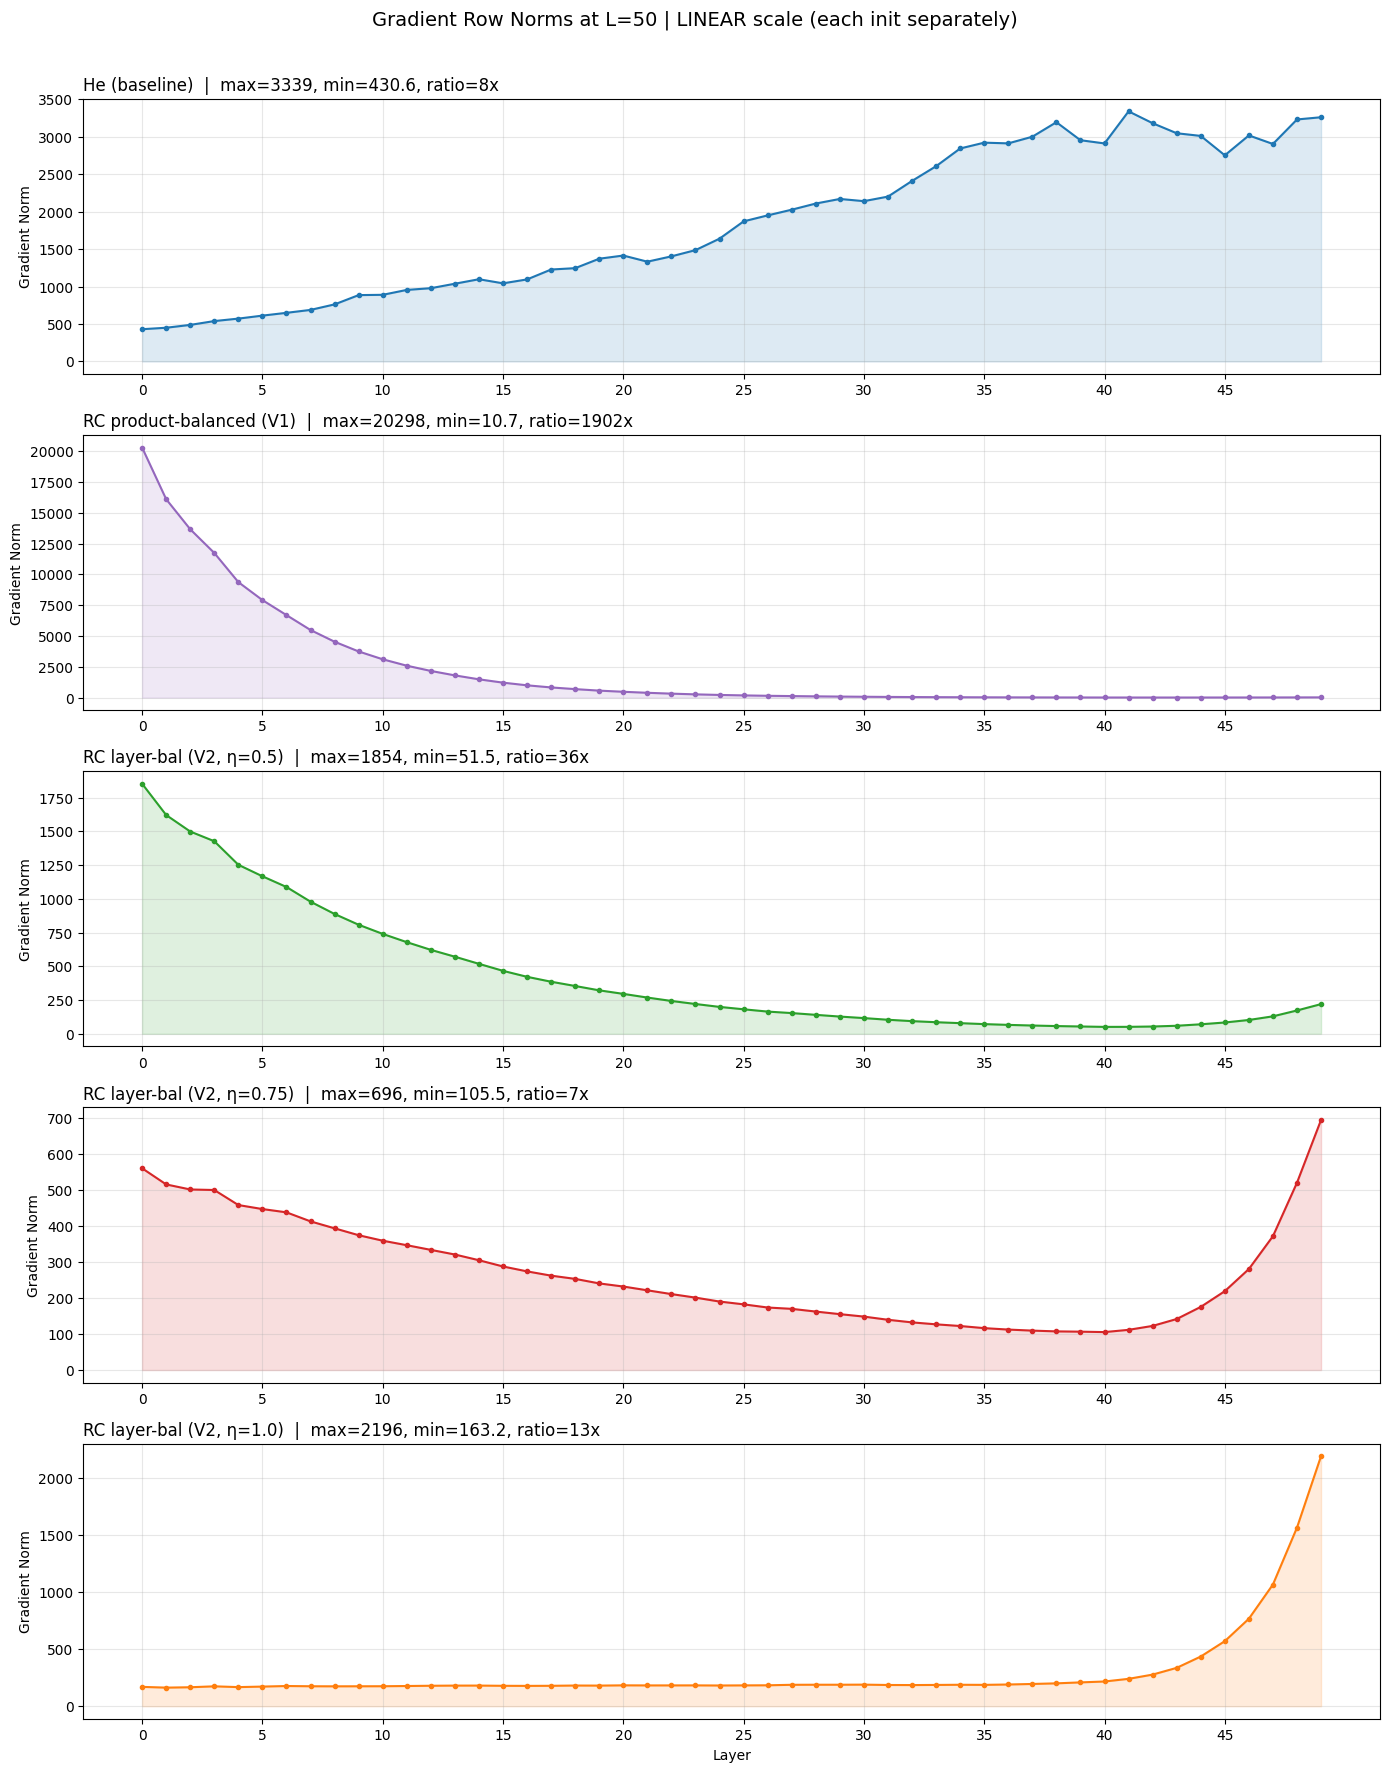

Saved to ../reports/latex/product_balanced_report/figures/gradient_norms_eta_comparison_L50.png


In [8]:
# === Updated Figure 2: Gradient Row Norms (each init, own y-axis) ===
n_inits = len(comparison_results)
fig, axes = plt.subplots(n_inits, 1, figsize=(14, 3.5 * n_inits))

for row, (label, (result, net, color)) in enumerate(comparison_results.items()):
    ax = axes[row]
    norms = result.get_mean_row_norms()
    layers = list(norms.keys())[:-1]  # exclude output
    vals = [norms[k] for k in layers]

    ax.plot(range(len(vals)), vals, 'o-', markersize=3, color=color, linewidth=1.5)
    ax.fill_between(range(len(vals)), vals, alpha=0.15, color=color)

    ratio = max(vals) / max(min(vals), 1e-30)
    ax.set_title(f'{label}  |  max={max(vals):.0f}, min={min(vals):.1f}, ratio={ratio:.0f}x',
                 fontsize=12, loc='left')
    ax.set_ylabel('Gradient Norm')
    ax.grid(True, alpha=0.3)
    n_ticks = min(10, len(vals))
    step = max(1, len(vals) // n_ticks)
    ax.set_xticks(range(0, len(vals), step))

axes[-1].set_xlabel('Layer')
fig.suptitle('Gradient Row Norms at L=50 | LINEAR scale (each init separately)',
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/gradient_norms_eta_comparison_L50.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGDIR}/gradient_norms_eta_comparison_L50.png')

## 6. Weight Std per Layer (the price of higher η)

The weight variance ratio matches theory exactly — it's deterministic from the
initialization formula. Higher η means earlier layers get much larger weights
and later layers get much smaller weights.

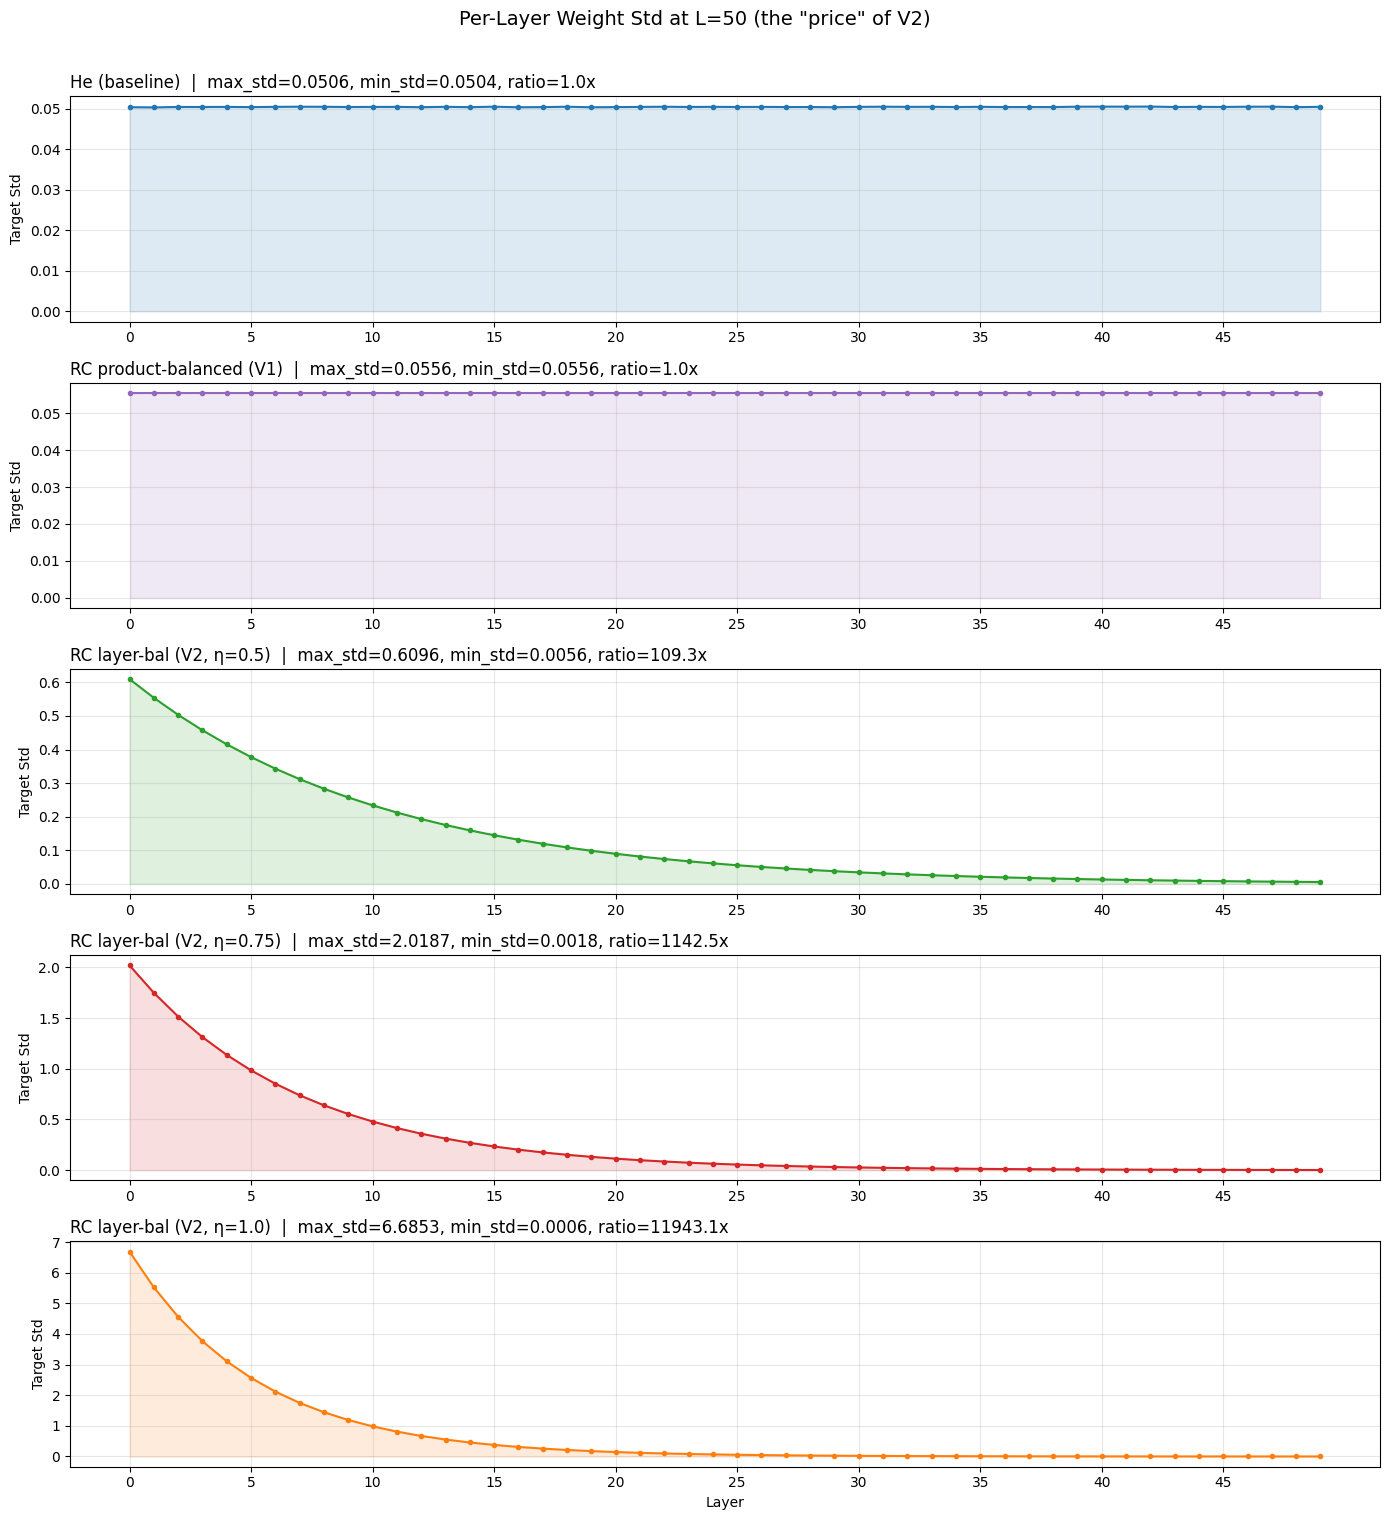

Saved to ../reports/latex/product_balanced_report/figures/weight_std_eta_comparison_L50.png


In [9]:
fig, axes = plt.subplots(n_inits, 1, figsize=(14, 3.0 * n_inits))

for row, (label, (result, net, color)) in enumerate(comparison_results.items()):
    ax = axes[row]
    weight_stds = [l.weight.std().item() for l in net.layers[:-1]]

    ax.plot(range(len(weight_stds)), weight_stds, 'o-', markersize=3,
            color=color, linewidth=1.5)
    ax.fill_between(range(len(weight_stds)), weight_stds, alpha=0.15, color=color)

    ratio = max(weight_stds) / max(min(weight_stds), 1e-30)
    ax.set_title(f'{label}  |  max_std={max(weight_stds):.4f}, '
                 f'min_std={min(weight_stds):.4f}, ratio={ratio:.1f}x',
                 fontsize=12, loc='left')
    ax.set_ylabel('Target Std')
    ax.grid(True, alpha=0.3)
    n_ticks = min(10, len(weight_stds))
    step = max(1, len(weight_stds) // n_ticks)
    ax.set_xticks(range(0, len(weight_stds), step))

axes[-1].set_xlabel('Layer')
fig.suptitle('Per-Layer Weight Std at L=50 (the "price" of V2)',
             fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(f'{FIGDIR}/weight_std_eta_comparison_L50.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGDIR}/weight_std_eta_comparison_L50.png')

## 7. Overlay on Pareto Frontier (updated Figure 4)

Overlay the empirical Pareto points on the theoretical Pareto hyperbolas
for multiple depths.

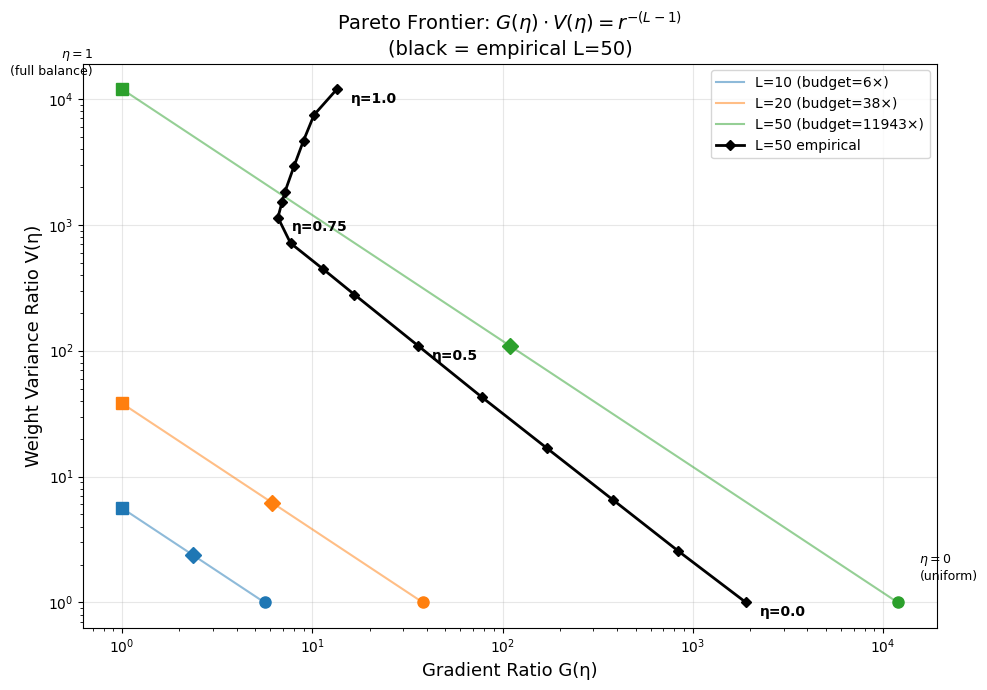

Saved to ../reports/latex/product_balanced_report/figures/pareto_with_empirical_L50.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

# Theoretical curves for L = 10, 20, 50
eta_fine = np.linspace(0, 1, 200)
depth_colors = {10: 'tab:blue', 20: 'tab:orange', 50: 'tab:green'}

for L, clr in depth_colors.items():
    G_curve = r ** (-(1 - eta_fine) * (L - 1))
    V_curve = r ** (-eta_fine * (L - 1))
    budget = r ** (-(L - 1))
    ax.plot(G_curve, V_curve, '-', color=clr, linewidth=1.5, alpha=0.5,
            label=f'L={L} (budget={budget:.0f}×)')

    # Mark η = 0, 0.5, 1
    for eta_mark, marker in [(0.0, 'o'), (0.5, 'D'), (1.0, 's')]:
        G_pt = r ** (-(1 - eta_mark) * (L - 1))
        V_pt = r ** (-eta_mark * (L - 1))
        ax.plot(G_pt, V_pt, marker=marker, color=clr, markersize=8, zorder=4)

# Empirical points for L=50
ax.plot(emp_G, emp_V, 'D-', color='black', linewidth=2, markersize=5,
        label='L=50 empirical', zorder=5)

# Annotate key empirical points
for d in sweep_data:
    if d['eta'] in [0.0, 0.5, 0.75, 1.0]:
        ax.annotate(f'η={d["eta"]}',
                    xy=(d['emp_G'], d['emp_V']),
                    xytext=(10, -10), textcoords='offset points',
                    fontsize=10, fontweight='bold')

ax.set_xlabel('Gradient Ratio G(η)', fontsize=13)
ax.set_ylabel('Weight Variance Ratio V(η)', fontsize=13)
ax.set_title(r'Pareto Frontier: $G(\eta) \cdot V(\eta) = r^{-(L-1)}$' + '\n'
             r'(black = empirical L=50)', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# Mark η labels on theoretical curve
ax.text(r**(-(DEPTH-1)) * 1.3, 1.5, r'$\eta=0$' + '\n(uniform)', fontsize=9, ha='left')
ax.text(0.7, r**(-(DEPTH-1)) * 1.3, r'$\eta=1$' + '\n(full balance)', fontsize=9, ha='right')

plt.tight_layout()
fig.savefig(f'{FIGDIR}/pareto_with_empirical_L50.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGDIR}/pareto_with_empirical_L50.png')

## 8. Gradient Row Norms: All on One Axis (log scale)

A single log-scale plot with He, V2 at η=0.5, V2 at η=0.75, and V2 at η=1.0
overlaid. This makes the shape of each curve directly comparable.

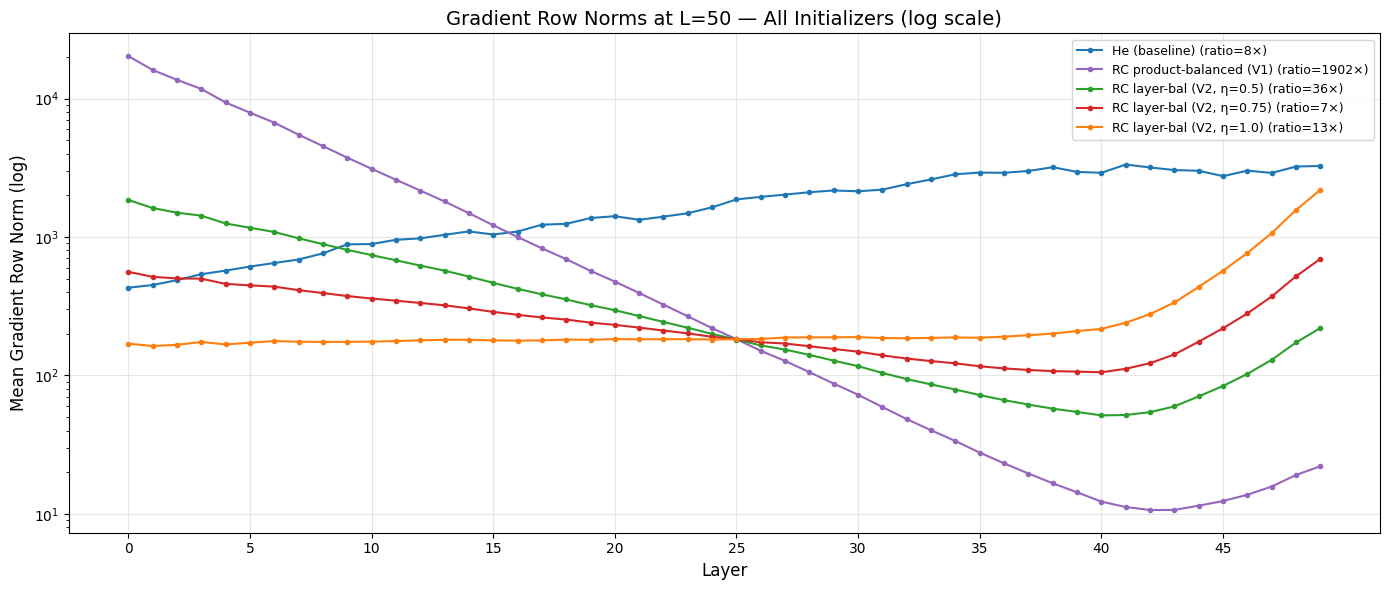

Saved to ../reports/latex/product_balanced_report/figures/gradient_norms_all_log_L50.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

for label, (result, net, color) in comparison_results.items():
    norms = result.get_mean_row_norms()
    layers = list(norms.keys())[:-1]
    vals = [norms[k] for k in layers]
    ratio = max(vals) / max(min(vals), 1e-30)
    ax.plot(range(len(vals)), vals, 'o-', markersize=3, color=color,
            linewidth=1.5, label=f'{label} (ratio={ratio:.0f}×)')

ax.set_yscale('log')
ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Mean Gradient Row Norm (log)', fontsize=12)
ax.set_title('Gradient Row Norms at L=50 — All Initializers (log scale)', fontsize=14)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
n_ticks = 10
n_layers = DEPTH
step = max(1, n_layers // n_ticks)
ax.set_xticks(range(0, n_layers, step))

plt.tight_layout()
fig.savefig(f'{FIGDIR}/gradient_norms_all_log_L50.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {FIGDIR}/gradient_norms_all_log_L50.png')

## 9. Discussion

### Key findings

1. **The empirical gradient ratio has a U-shape in η**, with a minimum around η≈0.75.
   Theory predicts a monotonic decrease to G=1× at η=1, but in practice the
   extreme weight variance at high η breaks the mean-field Gaussian assumptions.

2. **The weight variance ratio matches theory exactly** — it's deterministic from
   the initialization formula, not a statistical quantity.

3. **Best empirical gradient ratio** for V2 at L=50: **~6.6×** at η≈0.75,
   compared to He's ~8×. But V2 pays a weight std ratio of ~1,143×.

4. **The mean-field Pareto limit is unachievable in practice**: at finite width,
   the extreme weight imbalance at high η causes the theoretical G→1 prediction
   to break down. The empirical Pareto frontier bends away from the theoretical
   curve for η > 0.5.

### Why does the theory break at high η?

At η=1.0, layer 1 has std ≈ 6.9 while layer 50 has std ≈ 0.0006 — a factor
of ~11,943×. This means:
- The first few layers produce enormous pre-activations, violating the
  "moderate signal" assumption behind the mean-field analysis.
- The last layers have near-zero weights, causing extreme sensitivity to
  finite-sample and finite-width effects.
- The Gaussian approximation for activations breaks down when layer scales
  differ by orders of magnitude.